In [1]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install xgboost
!pip install category_encoders --upgrade

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.1/101.7 MB 10.0 MB/s eta 0:00:10
   - -------------------------------------- 4.5/101.7 MB 11.0 MB/s eta 0:00:09
   -- ------------------------------------- 7.1/101.7 MB 11.3 MB/s eta 0:00:09
   --- ------------------------------------ 8.7/101.7 MB 11.4 MB/s eta 0:00:09
   --- ------------------------------------ 9.4/101.7 MB 9.7 MB/s eta 0:00:10
   ---- ----------------------------------- 10.5/101.7 MB 8.2 MB/s eta 0:00:12
   ---- ----------------------------------- 11.3/101.7 MB 7.8 MB/s eta 0:00:12
   ---- ----------------------------------- 11.8/101.7 MB 7.3 MB/s eta 0:00:13
   ---- ----------------------------------- 12.3/101.7 MB 6.6 MB/s eta 0:00:14
   ---- ----------------------------------- 12.6/101.7 MB 6.2 MB/s eta 0:00:15
   ----- ---------------------------------- 12.8/101.7 MB 5.9 MB/s et

STARTING REGRESSION PIPELINE

1. Loading data...
 Data shape: (1000, 16)
 Columns: ['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']

2. Preparing features & target...

3. Splitting data...
 Train: (800, 13), Test: (200, 13)

4. Identifying feature types...
 Numeric features: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency']
 Low-card categorical features: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']
 High-card categorical features: []

5. Building preprocessing pipelines...

6. Selecting XGBRegressor model...

7. Creating full pipeline...

8. Training model...
   Using Gri

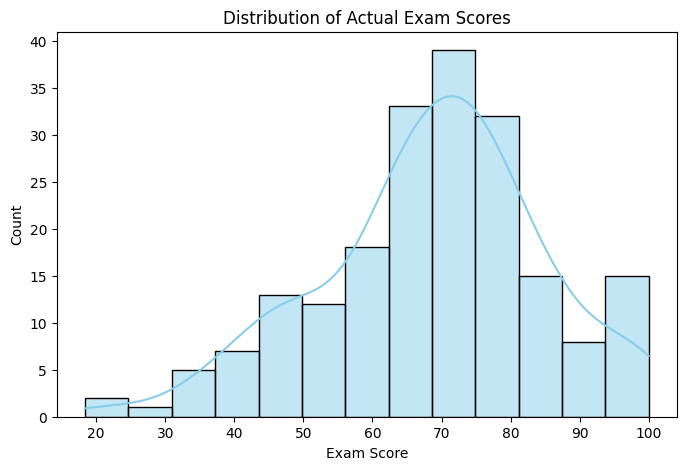

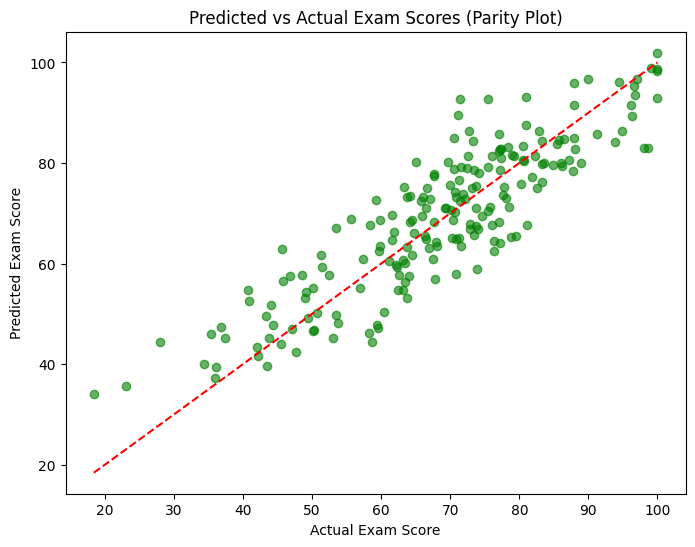

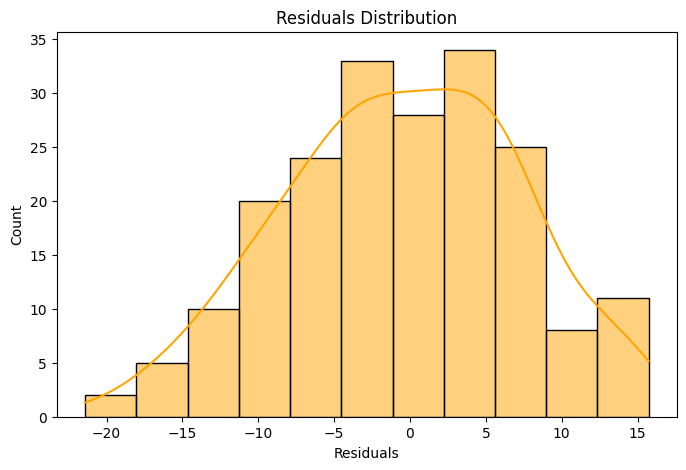

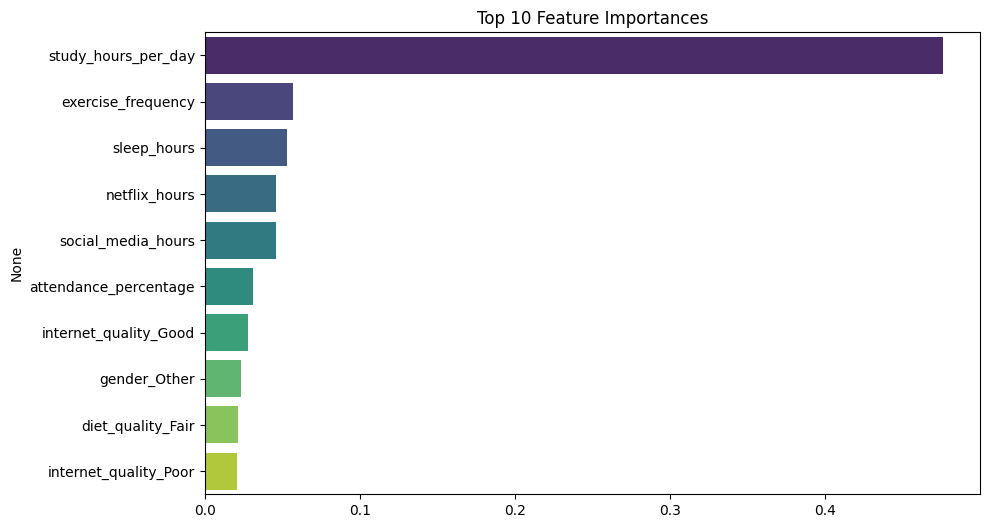

In [2]:
import pandas as pd
import numpy as np
import joblib
import json
from pathlib import Path

# ================== ML Libraries ===================
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import category_encoders as ce  # For frequency encoding of high-card categorical features
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ================== CONFIGURATION ===================
class Config:
    # Data settings
    DATA_PATH = 'student_habits_performance.csv'  # CSV file path
    TARGET_COL = 'exam_score'  # Column to predict
    TEST_SIZE = 0.2  # 20% data for testing
    RANDOM_STATE = 42  # For reproducibility

    # Model settings
    MODEL_TYPE = 'XGBRegressor'  # Model choice: RandomForest / GradientBoosting / XGBRegressor
    USE_GRID_SEARCH = True  # Use hyperparameter tuning if True

    # Feature settings
    EXCLUDE_COLS = ['mental_health_rating', 'student_id']  # Columns not used for prediction
    CATEGORICAL_COLS = []  # auto-detect categorical features if empty

    # Paths to save trained models and metrics
    MODEL_SAVE_PATH = 'models/best_model.pkl'
    PREPROCESSOR_SAVE_PATH = 'models/preprocessor.pkl'
    METRICS_SAVE_PATH = 'models/metrics.json'


# ================== PIPELINE FUNCTION ===================
def run_ml_pipeline(config: Config):
    print('='*60)
    print('STARTING REGRESSION PIPELINE')
    print('='*60)

    # 1. Load data
    print('\n1. Loading data...')
    df = pd.read_csv(config.DATA_PATH)
    print(f' Data shape: {df.shape}')
    print(f' Columns: {list(df.columns)}')

    # 2. Separate features (X) and target (y)
    print('\n2. Preparing features & target...')
    if config.TARGET_COL not in df.columns:
        raise ValueError(f'Target column "{config.TARGET_COL}" not found!')

    # Drop target column + excluded columns for features
    X = df.drop(columns=[config.TARGET_COL] + config.EXCLUDE_COLS)
    y = df[config.TARGET_COL]

    # 3. Split data into train and test sets
    print('\n3. Splitting data...')
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=config.TEST_SIZE,
        random_state=config.RANDOM_STATE
    )
    print(f' Train: {X_train.shape}, Test: {X_test.shape}')

    # 4. Identify numeric and categorical features
    print('\n4. Identifying feature types...')
    if not config.CATEGORICAL_COLS:
        categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    else:
        categorical_cols = config.CATEGORICAL_COLS

    numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in categorical_cols]

    # Split categorical features by cardinality
    LOW_CARD_THRESHOLD = 10
    low_card_cols = [c for c in categorical_cols if X_train[c].nunique() <= LOW_CARD_THRESHOLD]
    high_card_cols = [c for c in categorical_cols if X_train[c].nunique() > LOW_CARD_THRESHOLD]

    print(f' Numeric features: {numeric_cols}')
    print(f' Low-card categorical features: {low_card_cols}')
    print(f' High-card categorical features: {high_card_cols}')

    # 5. Build preprocessing pipelines
    print('\n5. Building preprocessing pipelines...')

    # Numeric features: fill missing values with median, then scale
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # Fill missing numeric values
        ('scaler', StandardScaler())  # Standardize numeric features
    ])

    # Low-cardinality categorical features: fill missing, then OneHotEncode
    low_card_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Fill missing
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # One-hot encode
    ])

    # High-cardinality categorical features: fill missing, then frequency encode
    high_card_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  
        ('freq', ce.CountEncoder(normalize=True))
    ])

    # Combine all pipelines
    preprocessor = ColumnTransformer([
        ('num', numeric_pipeline, numeric_cols),
        ('low_card', low_card_pipeline, low_card_cols),
        ('high_card', high_card_pipeline, high_card_cols)
    ])

    # 6. Select model
    print(f'\n6. Selecting {config.MODEL_TYPE} model...')
    if config.MODEL_TYPE == 'RandomForest':
        model = RandomForestRegressor(n_estimators=100, random_state=config.RANDOM_STATE, n_jobs=-1)
        param_grid = {
            'model__max_depth': [5, 10, 20],
            'model__min_samples_split': [2, 5, 10],
            'model__n_estimators': [50, 100, 200]
        }

    elif config.MODEL_TYPE == 'GradientBoosting':
        model = GradientBoostingRegressor(n_estimators=100, random_state=config.RANDOM_STATE)
        param_grid = {
            'model__learning_rate': [0.01, 0.1, 0.3],
            'model__max_depth': [3, 5, 7],
            'model__n_estimators': [100, 200]
        }

    elif config.MODEL_TYPE == 'XGBRegressor':
        model = XGBRegressor(n_estimators=100, random_state=config.RANDOM_STATE,
                             use_label_encoder=False, n_jobs=-1)
        param_grid = {
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.01, 0.1, 0.3],
            'model__subsample': [0.8, 1.0]
        }

    else:
        raise ValueError(f'Model "{config.MODEL_TYPE}" not supported')

    # 7. Full pipeline: combine preprocessing and model
    print('\n7. Creating full pipeline...')
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # 8. Train model
    print('\n8. Training model...')
    if config.USE_GRID_SEARCH:
        print('   Using GridSearchCV for hyperparameter tuning...')
        cv = KFold(n_splits=5, shuffle=True, random_state=config.RANDOM_STATE)
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=cv,
            scoring='r2',
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        print(f' Best parameters: {grid_search.best_params_}')
        print(f' Best CV score: {grid_search.best_score_:.4f}')
    else:
        print('   Training with default parameters...')
        pipeline.fit(X_train, y_train)
        best_model = pipeline

    # 9. Evaluate model
    print('\n9. Evaluating model...')
    y_pred = best_model.predict(X_test)
    metrics = {
        'mae': mean_absolute_error(y_test, y_pred),
        'mse': mean_squared_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'r2': r2_score(y_test, y_pred)
    }
    print('\n   Test Metrics:')
    for k, v in metrics.items():
        print(f'   {k.upper()}: {v:.4f}')

    # 10. Save artifacts: model, preprocessor, metrics
    print('\n10. Saving artifacts...')
    Path('models').mkdir(exist_ok=True)
    joblib.dump(best_model, config.MODEL_SAVE_PATH)
    joblib.dump(preprocessor, config.PREPROCESSOR_SAVE_PATH)
    with open(config.METRICS_SAVE_PATH, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f'   Model saved to: {config.MODEL_SAVE_PATH}')
    print(f'   Preprocessor saved to: {config.PREPROCESSOR_SAVE_PATH}')
    print(f'   Metrics saved to: {config.METRICS_SAVE_PATH}')

    print('\n' + '='*60)
    print('PIPELINE COMPLETED SUCCESSFULLY!')
    print('='*60)

    # Return all useful items for plotting and inspection
    return {
        'model': best_model,
        'preprocessor': preprocessor,
        'metrics': metrics,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'feature_names': {
            'numeric': numeric_cols,
            'low_card_categorical': low_card_cols,
            'high_card_categorical': high_card_cols
        }
    }


# ================== VISUALIZATION FUNCTION ===================
def plot_results(result):
    """
    Function to visualize:
    1. Target distribution
    2. Predicted vs Actual
    3. Residuals
    4. Feature importance """
    
    X_test = result['X_test']
    y_test = result['y_test']
    y_pred = result['y_pred']

    # 1. Target distribution
    plt.figure(figsize=(8,5))
    sns.histplot(y_test, kde=True, color='skyblue')
    plt.title('Distribution of Actual Exam Scores')
    plt.xlabel('Exam Score')
    plt.show()

    # 2. Predicted vs Actual
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.6, color='green')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Perfect prediction line
    plt.xlabel('Actual Exam Score')
    plt.ylabel('Predicted Exam Score')
    plt.title('Predicted vs Actual Exam Scores (Parity Plot)')
    plt.show()

    # 3. Residual plot
    residuals = y_test - y_pred
    plt.figure(figsize=(8,5))
    sns.histplot(residuals, kde=True, color='orange')
    plt.title('Residuals Distribution')
    plt.xlabel('Residuals')
    plt.show()

    # 4. Feature importance for tree-based models
    if hasattr(result['model'].named_steps['model'], 'feature_importances_'):
        importances = result['model'].named_steps['model'].feature_importances_

        # Corrected feature names after preprocessing
        ohe_features = result['model'].named_steps['preprocessor']\
                       .named_transformers_['low_card']\
                       .named_steps['ohe'].get_feature_names_out(result['feature_names']['low_card_categorical']).tolist()
        all_features = result['feature_names']['numeric'] + ohe_features + result['feature_names']['high_card_categorical']

        feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

        plt.figure(figsize=(10,6))
        sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10], palette='viridis')
        plt.title('Top 10 Feature Importances')
        plt.show()


# ================== MAIN ===================
if __name__ == '__main__':
    result = run_ml_pipeline(Config)
    plot_results(result)